In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("title.basics.tsv",sep="\t",nrows=10)

In [3]:
df.columns

Index(['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult',
       'startYear', 'endYear', 'runtimeMinutes', 'genres'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tconst          10 non-null     object
 1   titleType       10 non-null     object
 2   primaryTitle    10 non-null     object
 3   originalTitle   10 non-null     object
 4   isAdult         10 non-null     int64 
 5   startYear       10 non-null     int64 
 6   endYear         10 non-null     object
 7   runtimeMinutes  10 non-null     int64 
 8   genres          10 non-null     object
dtypes: int64(3), object(6)
memory usage: 852.0+ bytes


In [5]:
ratings=pd.read_csv("title.ratings.tsv", sep="\t",nrows=10)
ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2205
1,tt0000002,5.5,313
2,tt0000003,6.4,2318
3,tt0000004,5.1,197
4,tt0000005,6.2,3042


In [6]:
movies=pd.merge(df,ratings,on="tconst")

In [7]:
movies.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",5.7,2205
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short",5.5,313
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance",6.4,2318
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short",5.1,197
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short,6.2,3042


In [8]:
movies.shape

(10, 11)

In [9]:
movies.tail()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
5,tt0000006,short,Chinese Opium Den,Chinese Opium Den,0,1894,\N,1,Short,5.1,224
6,tt0000007,short,Corbett and Courtney Before the Kinetograph,Corbett and Courtney Before the Kinetograph,0,1894,\N,1,"Short,Sport",5.3,943
7,tt0000008,short,Edison Kinetoscopic Record of a Sneeze,Edison Kinetoscopic Record of a Sneeze,0,1894,\N,1,"Documentary,Short",5.4,2389
8,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,5.3,237
9,tt0000010,short,Leaving the Factory,La sortie de l'usine Lumière à Lyon,0,1895,\N,1,"Documentary,Short",6.8,8297


In [10]:
# Keep only movies (remove TV shows,shorts, etc.)

In [30]:
movies=movies[movies['titleType']=="movie"]

In [12]:
# Remove adult content

In [31]:
movies=movies[movies["isAdult"]==0]

In [14]:
# Replace IMDB missing values (\N) with Nan

In [32]:
movies.replace("\\N",pd.NA,inplace=True)

In [ ]:
# Load large dataset using chunks

In [33]:
chunks=pd.read_csv("title.basics.tsv",sep="\t", chunksize=50000)
df_list=[]

for chunk in chunks:
    chunk=chunk[chunk["titleType"]=="movie"]
    chunk=chunk[chunk["isAdult"]==0]
    df_list.append(chunk)
df=pd.concat(df_list)    

In [34]:
df.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
8,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance
144,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport"
498,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N
570,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,\N,70,"Action,Adventure,Biography"
587,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,\N,90,Drama


In [35]:
ratings=pd.read_csv("title.ratings.tsv",sep="\t")
ratings.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2205
1,tt0000002,5.5,313
2,tt0000003,6.4,2318
3,tt0000004,5.1,197
4,tt0000005,6.2,3042


In [ ]:
# Merge Data

In [36]:
movies = pd.merge(df, ratings, on="tconst")
movies.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance,5.3,237
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport",5.3,601
2,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N,3.5,26
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,\N,70,"Action,Adventure,Biography",6.0,1068
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,\N,90,Drama,5.0,39


In [20]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337614 entries, 0 to 337613
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tconst          337614 non-null  object 
 1   titleType       337614 non-null  object 
 2   primaryTitle    337612 non-null  object 
 3   originalTitle   337612 non-null  object 
 4   isAdult         337614 non-null  int64  
 5   startYear       337614 non-null  object 
 6   endYear         337614 non-null  object 
 7   runtimeMinutes  337614 non-null  object 
 8   genres          337614 non-null  object 
 9   averageRating   337614 non-null  float64
 10  numVotes        337614 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 28.3+ MB


In [37]:
movies['startYear'] = pd.to_numeric(movies['startYear'], errors='coerce')

In [38]:
movies.replace("\\N", pd.NA, inplace=True)

In [39]:
movies = movies.drop(columns=['endYear'])

In [24]:
# Top Rated Movies

In [40]:
top_movies = (movies[movies['numVotes'] > 10000]
    .sort_values(by='averageRating', ascending=False)
    .head(10))

In [29]:
top_movies

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes
61788,tt0111161,movie,The Shawshank Redemption,The Shawshank Redemption,0,1994.0,142,Drama,9.3,3178259
37314,tt0068646,movie,The Godfather,The Godfather,0,1972.0,175,"Crime,Drama",9.2,2219989
136136,tt0468569,movie,The Dark Knight,The Dark Knight,0,2008.0,152,"Action,Crime,Drama",9.1,3157766
265454,tt33175825,movie,Attack on Titan: The Last Attack,Shingeki no Kyojin: The Last Attack,0,2024.0,145,"Action,Adventure,Animation",9.1,26635
100661,tt0259534,movie,Ramayana: The Legend of Prince Rama,Ramayana: The Legend of Prince Rama,0,1993.0,135,"Action,Adventure,Animation",9.1,17680
98796,tt0252487,movie,The Chaos Class,Hababam Sinifi,0,1975.0,85,Comedy,9.1,46067
39220,tt0071562,movie,The Godfather Part II,The Godfather Part II,0,1974.0,202,"Crime,Drama",9.0,1491538
60203,tt0108052,movie,Schindler's List,Schindler's List,0,1993.0,195,"Biography,Drama,History",9.0,1581799
77884,tt0167260,movie,The Lord of the Rings: The Return of the King,The Lord of the Rings: The Return of the King,0,2003.0,201,"Adventure,Drama,Fantasy",9.0,2158768
24190,tt0050083,movie,12 Angry Men,12 Angry Men,0,1957.0,96,"Crime,Drama",9.0,980871


In [ ]:
# Genre Analysis

In [41]:
genres = movies['genres'].dropna().str.split(',').explode()

In [42]:
genre_count = genres.value_counts()

In [43]:
genre_count.head(10)

genres
Drama          154457
Comedy          81212
Documentary     55748
Romance         36881
Action          34958
Crime           29369
Thriller        29085
Horror          26341
Adventure       20635
Mystery         13469
Name: count, dtype: int64

In [ ]:
# Number of movies released each year

In [44]:
movies_per_year = movies.groupby('startYear').size()

movies_per_year.tail(10)

startYear
2017.0    10759
2018.0    10917
2019.0    11050
2020.0     9029
2021.0     9785
2022.0    11512
2023.0    11773
2024.0    11499
2025.0     9641
2026.0     1777
dtype: int64

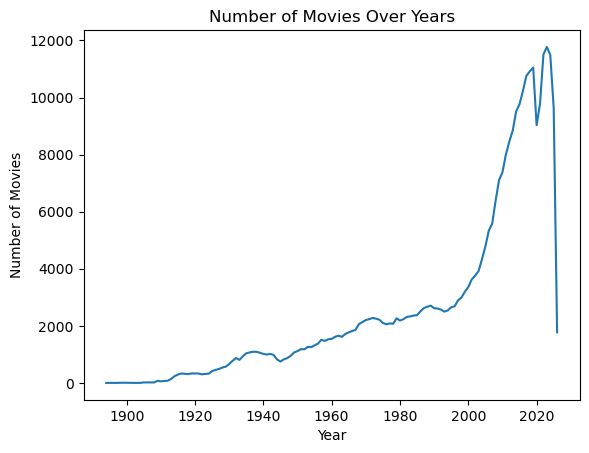

In [45]:
import matplotlib.pyplot as plt

movies_per_year.plot()

plt.title("Number of Movies Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

In [ ]:
# Export Data

In [49]:
movies.to_csv("clean_movies.csv", index=False)

In [48]:
movies .shape

(337614, 10)